# MIMIC-IV Microbiology Exploration

This notebook performs EDA on the `microbiologyevents` table. It maps all
test × specimen combinations to 37 fine-grained clinical panels for the
CDSS reinforcement learning environment (feature slots F20–F56), then
analyses coverage, positivity, organism patterns, antibiotic resistance,
temporal ordering, and panel co-occurrence.

The 37-panel design keys on `(test_name, spec_type_desc)` pairs rather than
specimen type alone, reflecting that the same test ordered on different
specimens represents a clinically distinct event. Post-mortem specimens are
excluded to prevent target leakage (Y1 = in-hospital mortality).


## Section 1: Setup & Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

base_path = '~/data/physionet.org/files/mimiciv/3.1/hosp/'

print("Loading microbiologyevents.csv.gz ...")
micro_df = pd.read_csv(
    base_path + 'microbiologyevents.csv.gz',
    dtype={'quantity': 'string'},
    low_memory=False,
)
print(f"Full dataset (incl. outpatient rows): {micro_df.shape[0]:,} rows, {micro_df.shape[1]} columns")

print("Loading admissions.csv.gz ...")
adm_df = pd.read_csv(base_path + 'admissions.csv.gz')
total_admissions = adm_df['hadm_id'].nunique()
print(f"Total unique hospital admissions (hadm_id): {total_admissions:,}")

# Admission-linked subset — used in sections 4, 7, 8, 9, 10, 11
micro_adm_df = micro_df.dropna(subset=['hadm_id']).copy()
print(f"Admission-linked rows (hadm_id not null): {micro_adm_df.shape[0]:,}")
print(f"Outpatient rows (hadm_id null)           : {micro_df['hadm_id'].isna().sum():,}")
print("\nColumn overview:")
print(micro_df.dtypes)


## Section 2: Relation of `spec_type_desc` to `test_name`

In [ ]:
TOP_N_SPEC = 20

full_pivot = (
    micro_df
    .pivot_table(
        index='test_name',
        columns='spec_type_desc',
        aggfunc='size',
        fill_value=0,
    )
)

row_totals = full_pivot.sum(axis=1).sort_values(ascending=False)
full_pivot = full_pivot.loc[row_totals.index]

top_spec_per_test = set()
for test in full_pivot.index:
    row = full_pivot.loc[test]
    top_specs = row.sort_values(ascending=False).head(TOP_N_SPEC).index.tolist()
    top_spec_per_test.update(top_specs)

col_order = micro_df['spec_type_desc'].value_counts().index.tolist()
ordered_cols = [c for c in col_order if c in top_spec_per_test]
pivot = full_pivot.reindex(columns=ordered_cols, fill_value=0)
n_rows, n_cols = len(pivot), len(pivot.columns)

zero_mask = pivot == 0
fig_height = max(14, n_rows * 0.38)
fig_width  = max(22, n_cols * 0.58)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    pivot, mask=zero_mask, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, linecolor='#cccccc', ax=ax,
    annot_kws={'size': 7}, cbar_kws={'shrink': 0.5, 'label': 'Event count'},
)
sns.heatmap(
    pivot, mask=~zero_mask, annot=False,
    cmap=mpl.colors.ListedColormap(['black']),
    linewidths=0.4, linecolor='#cccccc', ax=ax, cbar=False,
)
ax.set_title(
    f'Test Name × Specimen Type — Event Counts\n'
    f'({n_rows} tests × top-{TOP_N_SPEC} specimen types per test, '
    f'ordered by global frequency  |  black = 0 occurrences)',
    fontsize=13, pad=14,
)
ax.set_xlabel('Specimen Type', fontsize=11)
ax.set_ylabel('Test Name (sorted by total events)', fontsize=11)
ax.tick_params(axis='x', labelrotation=60, labelsize=8)
ax.tick_params(axis='y', labelrotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

COL_WIDTH, NAME_WIDTH = 7, 48
abbrev = {c: c[:COL_WIDTH - 1] for c in pivot.columns}
header = f"{'test_name':<{NAME_WIDTH}}" + ''.join(f"{abbrev[c]:>{COL_WIDTH}}" for c in pivot.columns)
print(f"\n=== Test × Specimen Type Event Count Table ===")
print(header)
print('-' * len(header))
for test_name in pivot.index:
    row = f"{test_name:<{NAME_WIDTH}}"
    for col in pivot.columns:
        val = pivot.loc[test_name, col]
        row += f"{'.' if val == 0 else str(int(val)):>{COL_WIDTH}}"
    print(row)
print(f"\nTotal: {n_rows} tests × {n_cols} specimen type columns shown")
print(f"(full dataset: {micro_df['test_name'].nunique()} unique tests, "
      f"{micro_df['spec_type_desc'].nunique()} unique specimen types)")


## Section 3: Appearances per Test (The Long Tail)

Total unique test_name values: 173

Summary statistics of test frequencies:
count    1.730000e+02
mean     2.305332e+04
std      1.116816e+05
min      1.000000e+00
25%      1.060000e+02
50%      1.387000e+03
75%      9.728000e+03
max      1.230152e+06

Top 10 most frequent tests:
                                                    test_name   count
                                                URINE CULTURE 1230152
                                       Blood Culture, Routine  742344
                                                WOUND CULTURE  196031
                                          RESPIRATORY CULTURE  186790
                                                   GRAM STAIN  179660
                                                FLUID CULTURE  130371
                                            ANAEROBIC CULTURE   88294
                                                       TISSUE   83369
                                                  MRSA SCREEN   77459
Chlamydia trachomat

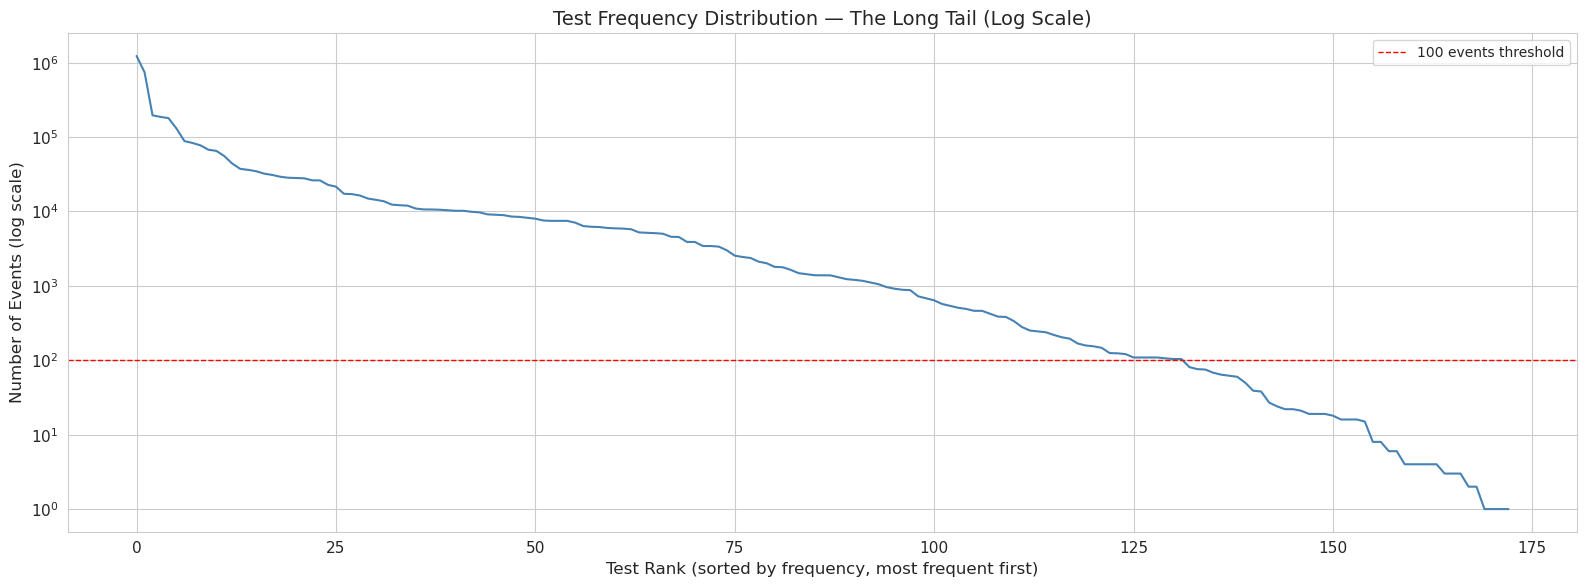


Tests with fewer than 100 events: 41 (23.7% of all tests)


In [86]:
# --- Test frequency distribution ---
test_counts = (
    micro_df.groupby('test_name')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f"Total unique test_name values: {test_counts.shape[0]}")
print("\nSummary statistics of test frequencies:")
print(test_counts['count'].describe().to_string())
print(f"\nTop 10 most frequent tests:")
print(test_counts.head(10).to_string(index=False))
print(f"\nBottom 10 least frequent tests:")
print(test_counts.tail(10).to_string(index=False))

# --- Line chart: Long Tail of test frequencies ---
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    range(len(test_counts)),
    test_counts['count'].values,
    color='steelblue',
    linewidth=1.5
)
ax.set_yscale('log')
ax.set_title('Test Frequency Distribution — The Long Tail (Log Scale)', fontsize=14)
ax.set_xlabel('Test Rank (sorted by frequency, most frequent first)', fontsize=12)
ax.set_ylabel('Number of Events (log scale)', fontsize=12)
ax.axhline(y=100, color='red', linestyle='--', linewidth=1, label='100 events threshold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

rare_tests = (test_counts['count'] < 100).sum()
print(f"\nTests with fewer than 100 events: {rare_tests} ({rare_tests / len(test_counts) * 100:.1f}% of all tests)")

## Section 4: Data Sparsity & Clinical Yield

In [ ]:
total_events = len(micro_adm_df)

negative_keywords = ['NO GROWTH', 'CANCELLED', 'VOID']
has_org = micro_adm_df['org_name'].notna()
is_negative_keyword = micro_adm_df['org_name'].str.upper().str.contains(
    '|'.join(negative_keywords), na=False
)
positive_mask = has_org & ~is_negative_keyword
n_positive = positive_mask.sum()
yield_rate = n_positive / total_events * 100
print(f"=== Yield Sparsity (Positivity Rate) ===")
print(f"  Total microbiology events (admission-linked): {total_events:,}")
print(f"  Events with organism isolated               : {n_positive:,}")
print(f"  Positivity Rate                             : {yield_rate:.2f}%")
print(f"  Yield Sparsity (negative rate)              : {100 - yield_rate:.2f}%")

n_with_susceptibility = micro_adm_df['ab_name'].notna().sum()
susceptibility_rate = n_with_susceptibility / total_events * 100
print(f"\n=== Susceptibility Sparsity ===")
print(f"  Events with antibiotic susceptibility data: {n_with_susceptibility:,}")
print(f"  Susceptibility Coverage Rate              : {susceptibility_rate:.2f}%")
print(f"  Susceptibility Sparsity                   : {100 - susceptibility_rate:.2f}%")

admissions_with_micro = micro_adm_df['hadm_id'].nunique()
admission_coverage = admissions_with_micro / total_admissions * 100
print(f"\n=== Admission-level Sparsity ===")
print(f"  Total hospital admissions                  : {total_admissions:,}")
print(f"  Admissions with \u22651 microbiology event      : {admissions_with_micro:,}")
print(f"  Micro Coverage (% admissions with micro)   : {admission_coverage:.2f}%")
print(f"  Admission-level Sparsity                   : {100 - admission_coverage:.2f}%")


## Section 5: Obsolete 7-Panel Mapping (Removed)

The original 7-panel mapping by `spec_type_desc` alone has been superseded
by the 37-panel `(test_name, spec_type_desc)` design in Section 6.
This section is intentionally left empty.


In [ ]:
# Section 5 (7-panel mapping) removed — see Section 6 for the 37-panel design.


## Section 6: 37-Panel (Test × Specimen) Groupings

The 37-panel design keys on `(test_name, spec_type_desc)` pairs. It runs
on the **full dataset** including outpatient rows (null `hadm_id`) to capture
the true clinical scope of each panel.

Seven architectural corrections were applied relative to the initial design:
1. Post-mortem specimens excluded — target leakage prevention (Y1 = in-hospital mortality)
2. Fluid panels split — `pleural_culture`, `peritoneal_culture`, `joint_fluid_culture`, `fluid_culture` mirror F8/F9/F12 lab architecture
3. `bone_marrow_culture` — mirrors F11 lab slot
4. `hardware_and_lines_culture` — separates CLABSI/device workup from wound cultures
5. `respiratory_sputum_bal` split — `respiratory_invasive` vs `respiratory_non_invasive`
6. `urine_antigen_naat` split — `urinary_antigens` (Legionella); GC/Chlamydia NAAT absorbed into `gc_chlamydia_sti`
7. `urine_viral` — CMV viruria isolated from routine UTI workup


In [ ]:
# =============================================================================
# Section 6: 37-Panel (test_name × spec_type_desc) grouping
# =============================================================================

PANELS_37 = {
    "blood_culture_routine": [
        ("Blood Culture, Routine", "BLOOD CULTURE"),
        ("BLOOD/FUNGAL CULTURE", "BLOOD CULTURE ( MYCO/F LYTIC BOTTLE)"),
        ("BLOOD/AFB CULTURE", "BLOOD CULTURE ( MYCO/F LYTIC BOTTLE)"),
        ("BRUCELLA BLOOD CULTURE", "BLOOD CULTURE"),
        ("M. furfur Blood Culture", "BLOOD CULTURE"),
        ("BARTONELLA BLOOD CULTURE", "BLOOD CULTURE"),
        ("Blood Culture, Neonate", "BLOOD CULTURE - NEONATE"),
        ("AEROBIC BOTTLE", "BLOOD CULTURE"),
        ("ANAEROBIC BOTTLE", "BLOOD CULTURE"),
        ("ISOLATE FOR MIC", "Isolate"),
        ("M.FURFUR CULTURE", "BLOOD CULTURE"),
        ("BLOOD/FUNGAL CULTURE", "BLOOD CULTURE"),
        ("BLOOD/AFB CULTURE", "BLOOD CULTURE"),
        ("ISOLATE FOR MIC", "BLOOD CULTURE"),
    ],
    "blood_bottle_gram_stain": [
        ("Aerobic Bottle Gram Stain", "BLOOD CULTURE"),
        ("Anaerobic Bottle Gram Stain", "BLOOD CULTURE"),
        ("Myco-F Bottle Gram Stain", "BLOOD CULTURE ( MYCO/F LYTIC BOTTLE)"),
        ("Pediatric Bottle Gram Stain", "Isolate"),
        ("Fluid Culture in Bottles", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("Stem Cell Aer/Ana Culture", "Stem Cell - Blood Culture"),
        ("STEM CELL - AEROBIC BOTTLE", "Stem Cell - Blood Culture"),
        ("STEM CELL - ANAEROBIC BOTTLE", "Stem Cell - Blood Culture"),
        ("Aerobic Bottle Gram Stain", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("Anaerobic Bottle Gram Stain", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("ANAEROBIC BOTTLE", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("AEROBIC BOTTLE", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
    ],
    "urine_culture": [
        ("URINE CULTURE", "URINE"),
        ("URINE CULTURE", "URINE,KIDNEY"),
        ("URINE CULTURE", "URINE,SUPRAPUBIC ASPIRATE"),
        ("REFLEX URINE CULTURE", "URINE"),
        ("URINE-GRAM STAIN - UNSPUN", "URINE"),
        ("URINE-GRAM STAIN - UNSPUN", "URINE,KIDNEY"),
        ("FLUID CULTURE", "URINE,KIDNEY"),
        ("ANAEROBIC CULTURE", "URINE"),
        ("FLUID CULTURE", "URINE"),
        ("ANAEROBIC CULTURE", "URINE,KIDNEY"),
        ("FLUID CULTURE", "URINE,SUPRAPUBIC ASPIRATE"),
        ("ISOLATE FOR MIC", "URINE"),
    ],
    "urine_viral": [
        ("VIRAL CULTURE", "URINE"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "URINE"),
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "URINE"),
    ],
    "urinary_antigens": [
        ("Legionella Urinary Antigen ", "URINE"),
    ],
    "respiratory_non_invasive": [
        ("RESPIRATORY CULTURE", "SPUTUM"),
        ("RESPIRATORY CULTURE", "ASPIRATE"),
        ("ISOLATE FOR MIC", "SPUTUM"),
    ],
    "respiratory_invasive": [
        ("RESPIRATORY CULTURE", "BRONCHOALVEOLAR LAVAGE"),
        ("RESPIRATORY CULTURE", "BRONCHIAL WASHINGS"),
        ("RESPIRATORY CULTURE", "Mini-BAL"),
        ("RESPIRATORY CULTURE", "BRONCHIAL BRUSH - PROTECTED"),
        ("RESPIRATORY CULTURE", "BRONCHIAL BRUSH"),
        ("RESPIRATORY CULTURE", "TRACHEAL ASPIRATE"),
    ],
    "respiratory_afb": [
        ("ACID FAST CULTURE", "SPUTUM"),
        ("ACID FAST SMEAR", "SPUTUM"),
        ("ACID FAST CULTURE", "BRONCHOALVEOLAR LAVAGE"),
        ("ACID FAST SMEAR", "BRONCHOALVEOLAR LAVAGE"),
        ("ACID FAST CULTURE", "BRONCHIAL WASHINGS"),
        ("ACID FAST SMEAR", "BRONCHIAL WASHINGS"),
        ("ACID FAST CULTURE", "Mini-BAL"),
        ("ACID FAST SMEAR", "Mini-BAL"),
        ("ACID FAST CULTURE", "BRONCHIAL BRUSH"),
        ("ACID FAST SMEAR", "BRONCHIAL BRUSH"),
        ("ACID FAST CULTURE", "BRONCHIAL BRUSH - PROTECTED"),
        ("ACID FAST SMEAR", "BRONCHIAL BRUSH - PROTECTED"),
        ("ACID FAST CULTURE", "TRACHEAL ASPIRATE"),
        ("ACID FAST SMEAR", "TRACHEAL ASPIRATE"),
        ("MTB Direct Amplification", "SPUTUM"),
        ("MTB Direct Amplification", "BRONCHOALVEOLAR LAVAGE"),
        ("GEN-PROBE AMPLIFIED M. TUBERCULOSIS DIRECT TEST (MTD)", "SPUTUM"),
        ("GEN-PROBE AMPLIFIED M. TUBERCULOSIS DIRECT TEST (MTD)", "BRONCHOALVEOLAR LAVAGE"),
        ("NOCARDIA CULTURE", "BRONCHOALVEOLAR LAVAGE"),
        ("NOCARDIA CULTURE", "SPUTUM"),
        ("NOCARDIA CULTURE", "Mini-BAL"),
        ("MODIFIED ACID-FAST STAIN FOR NOCARDIA", "SPUTUM"),
        ("MODIFIED ACID-FAST STAIN FOR NOCARDIA", "BRONCHOALVEOLAR LAVAGE"),
    ],
    "respiratory_viral": [
        ("Respiratory Viral Antigen Screen", "Rapid Respiratory Viral Screen & Culture"),
        ("Respiratory Viral Culture", "Rapid Respiratory Viral Screen & Culture"),
        ("Respiratory Virus Identification", "Rapid Respiratory Viral Screen & Culture"),
        ("Respiratory Virus Identification", "Influenza A/B by DFA"),
        ("DIRECT INFLUENZA A ANTIGEN TEST", "Influenza A/B by DFA"),
        ("DIRECT INFLUENZA B ANTIGEN TEST", "Influenza A/B by DFA"),
        ("DIRECT INFLUENZA A ANTIGEN TEST", "RAPID RESPIRATORY VIRAL ANTIGEN TEST"),
        ("DIRECT INFLUENZA B ANTIGEN TEST", "RAPID RESPIRATORY VIRAL ANTIGEN TEST"),
        ("DIRECT INFLUENZA A ANTIGEN TEST", "ASPIRATE"),
        ("DIRECT INFLUENZA B ANTIGEN TEST", "ASPIRATE"),
        ("DIRECT INFLUENZA A ANTIGEN TEST", "SWAB"),
        ("DIRECT INFLUENZA B ANTIGEN TEST", "SWAB"),
        ("DIRECT RSV ANTIGEN TEST", "Rapid Respiratory Viral Screen & Culture"),
        ("Respiratory Viral Antigen Screen", "BRONCHOALVEOLAR LAVAGE"),
        ("Respiratory Viral Antigen Screen", "Influenza A/B by DFA"),
        ("Respiratory Viral Antigen Screen", "ASPIRATE"),
        ("Respiratory Viral Antigen Screen", "SWAB"),
        ("Respiratory Viral Culture", "BRONCHOALVEOLAR LAVAGE"),
        ("Respiratory Viral Culture", "Influenza A/B by DFA"),
        ("Respiratory Viral Culture", "ASPIRATE"),
        ("Respiratory Viral Culture", "SWAB"),
        ("VIRAL CULTURE", "Rapid Respiratory Viral Screen & Culture"),
        ("VIRAL CULTURE", "Influenza A/B by DFA"),
        ("VIRAL CULTURE", "BRONCHIAL WASHINGS"),
        ("VIRAL CULTURE", "RAPID RESPIRATORY VIRAL ANTIGEN TEST"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "Mini-BAL"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "BRONCHIAL WASHINGS"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "Rapid Respiratory Viral Screen & Culture"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "SPUTUM"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "BRONCHOALVEOLAR LAVAGE"),
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "BRONCHOALVEOLAR LAVAGE"),
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "BRONCHIAL WASHINGS"),
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "Rapid Respiratory Viral Screen & Culture"),
    ],
    "respiratory_pcp_legionella": [
        ("Immunofluorescent test for Pneumocystis jirovecii (carinii)", "SPUTUM"),
        ("Immunofluorescent test for Pneumocystis jirovecii (carinii)", "BRONCHOALVEOLAR LAVAGE"),
        ("Immunofluorescent test for Pneumocystis jirovecii (carinii)", "BRONCHIAL WASHINGS"),
        ("Immunofluorescent test for Pneumocystis jirovecii (carinii)", "Mini-BAL"),
        ("Immunofluorescent test for Pneumocystis jirovecii (carinii)", "TISSUE"),
        ("IMMUNOFLUORESCENT TEST FOR PNEUMOCYSTIS CARINII", "SPUTUM"),
        ("IMMUNOFLUORESCENT TEST FOR PNEUMOCYSTIS CARINII", "BRONCHOALVEOLAR LAVAGE"),
        ("LEGIONELLA CULTURE", "SPUTUM"),
        ("LEGIONELLA CULTURE", "BRONCHOALVEOLAR LAVAGE"),
        ("LEGIONELLA CULTURE", "BRONCHIAL WASHINGS"),
        ("LEGIONELLA CULTURE", "Mini-BAL"),
        ("LEGIONELLA CULTURE", "TISSUE"),
        ("LEGIONELLA CULTURE", "SWAB"),
        ("LEGIONELLA CULTURE", "PLEURAL FLUID"),
        ("NOCARDIA CULTURE", "BRONCHIAL WASHINGS"),
        ("NOCARDIA CULTURE", "Mini-BAL"),
        ("NOCARDIA CULTURE", "TRACHEAL ASPIRATE"),
    ],
    "gram_stain_respiratory": [
        ("GRAM STAIN", "SPUTUM"),
        ("GRAM STAIN", "BRONCHOALVEOLAR LAVAGE"),
        ("GRAM STAIN", "BRONCHIAL WASHINGS"),
        ("GRAM STAIN", "Mini-BAL"),
        ("GRAM STAIN", "TRACHEAL ASPIRATE"),
        ("GRAM STAIN", "BRONCHIAL BRUSH"),
    ],
    "gram_stain_wound_tissue": [
        ("GRAM STAIN", "SWAB"),
        ("GRAM STAIN", "TISSUE"),
        ("GRAM STAIN", "ABSCESS"),
        ("GRAM STAIN", "FLUID,OTHER"),
        ("GRAM STAIN", "BILE"),
        ("GRAM STAIN", "DIALYSIS FLUID"),
        ("GRAM STAIN", "ASPIRATE"),
        ("GRAM STAIN", "BIOPSY"),
        ("GRAM STAIN", "EAR"),
        ("GRAM STAIN", "FOOT CULTURE"),
        ("GRAM STAIN", "URINE"),
        ("GRAM STAIN", "FLUID WOUND"),
        ("GRAM STAIN", "STOOL"),
    ],
    "gram_stain_csf": [
        ("GRAM STAIN", "CSF;SPINAL FLUID"),
    ],
    "wound_culture": [
        ("WOUND CULTURE", "SWAB"),
        ("WOUND CULTURE", "ABSCESS"),
        ("WOUND CULTURE", "FOOT CULTURE"),
        ("WOUND CULTURE", "TISSUE"),
        ("WOUND CULTURE", "FLUID,OTHER"),
        ("WOUND CULTURE", "FLUID WOUND"),
        ("WOUND CULTURE", "ASPIRATE"),
        ("WOUND CULTURE", "CORNEAL EYE SCRAPINGS"),
        ("ANAEROBIC CULTURE", "SWAB"),
        ("ANAEROBIC CULTURE", "ABSCESS"),
        ("ANAEROBIC CULTURE", "TISSUE"),
        ("ANAEROBIC CULTURE", "ASPIRATE"),
        ("ANAEROBIC CULTURE", "BIOPSY"),
        ("ANAEROBIC CULTURE", "FOOT CULTURE"),
        ("ANAEROBIC CULTURE", "FLUID WOUND"),
        ("ANAEROBIC CULTURE", "FLUID,OTHER"),
        ("TISSUE", "TISSUE"),
        ("TISSUE", "BIOPSY"),
        ("TISSUE", "ABSCESS"),
        ("TISSUE CULTURE-TISSUE", "TISSUE"),
        ("RESPIRATORY CULTURE", "SWAB"),
        ("RESPIRATORY CULTURE", "EAR"),
        ("RESPIRATORY CULTURE", "EYE"),
        ("RESPIRATORY CULTURE", "Staph aureus swab"),
        ("RESPIRATORY CULTURE", "THROAT CULTURE"),
        ("RESPIRATORY CULTURE", "THROAT FOR STREP"),
        ("RESPIRATORY CULTURE", "FLUID,OTHER"),
        ("FLUID CULTURE", "SWAB"),
        ("FLUID CULTURE", "TISSUE"),
        ("NOCARDIA CULTURE", "SWAB"),
        ("NOCARDIA CULTURE", "ABSCESS"),
        ("NOCARDIA CULTURE", "TISSUE"),
        ("MODIFIED ACID-FAST STAIN FOR NOCARDIA", "TISSUE"),
        ("ISOLATE FOR MIC", "TISSUE"),
        ("ANAEROBIC CULTURE", "POSTMORTEM CULTURE"),
    ],
    "hardware_and_lines_culture": [
        ("WOUND CULTURE", "CATHETER TIP-IV"),
        ("WOUND CULTURE", "FOREIGN BODY"),
        ("ANAEROBIC CULTURE", "FOREIGN BODY"),
        ("ANAEROBIC CULTURE", "Foreign Body - Sonication Culture"),
        ("FUNGAL CULTURE", "FOREIGN BODY"),
        ("ACID FAST CULTURE", "FOREIGN BODY"),
        ("ACID FAST SMEAR", "FOREIGN BODY"),
        ("GRAM STAIN", "FOREIGN BODY"),
        ("GRAM STAIN", "CATHETER TIP-IV"),
        ("GRAM STAIN", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("POTASSIUM HYDROXIDE PREPARATION", "FOREIGN BODY"),
        ("Sonication culture, prosthetic joint", "Foreign Body - Sonication Culture"),
        ("Sonication culture, prosthetic joint", "FOREIGN BODY"),
    ],
    "pleural_culture": [
        ("FLUID CULTURE", "PLEURAL FLUID"),
        ("ANAEROBIC CULTURE", "PLEURAL FLUID"),
        ("FUNGAL CULTURE", "PLEURAL FLUID"),
        ("ACID FAST CULTURE", "PLEURAL FLUID"),
        ("ACID FAST SMEAR", "PLEURAL FLUID"),
        ("POTASSIUM HYDROXIDE PREPARATION", "PLEURAL FLUID"),
        ("NOCARDIA CULTURE", "PLEURAL FLUID"),
        ("Respiratory Viral Culture", "PLEURAL FLUID"),
        ("VIRAL CULTURE", "PLEURAL FLUID"),
        ("GRAM STAIN", "PLEURAL FLUID"),
    ],
    "peritoneal_culture": [
        ("FLUID CULTURE", "PERITONEAL FLUID"),
        ("ANAEROBIC CULTURE", "PERITONEAL FLUID"),
        ("FUNGAL CULTURE", "PERITONEAL FLUID"),
        ("ACID FAST CULTURE", "PERITONEAL FLUID"),
        ("ACID FAST SMEAR", "PERITONEAL FLUID"),
        ("POTASSIUM HYDROXIDE PREPARATION", "PERITONEAL FLUID"),
        ("Fluid Culture in Bottles", "PERITONEAL FLUID"),
        ("GRAM STAIN", "PERITONEAL FLUID"),
    ],
    "joint_fluid_culture": [
        ("FLUID CULTURE", "JOINT FLUID"),
        ("ANAEROBIC CULTURE", "JOINT FLUID"),
        ("FUNGAL CULTURE", "JOINT FLUID"),
        ("ACID FAST CULTURE", "JOINT FLUID"),
        ("ACID FAST SMEAR", "JOINT FLUID"),
        ("POTASSIUM HYDROXIDE PREPARATION", "JOINT FLUID"),
        ("FLUID CULTURE", "PROSTHETIC JOINT FLUID"),
        ("ACID FAST CULTURE", "PROSTHETIC JOINT FLUID"),
        ("ACID FAST SMEAR", "PROSTHETIC JOINT FLUID"),
        ("FUNGAL CULTURE", "PROSTHETIC JOINT FLUID"),
        ("Anaerobic culture, Prosthetic Joint Fluid", "PROSTHETIC JOINT FLUID"),
        ("Sonication culture, prosthetic joint", "PROSTHETIC JOINT FLUID"),
        ("GRAM STAIN", "JOINT FLUID"),
        ("GRAM STAIN", "PROSTHETIC JOINT FLUID"),
    ],
    "fluid_culture": [
        ("FLUID CULTURE", "BILE"),
        ("FLUID CULTURE", "DIALYSIS FLUID"),
        ("FLUID CULTURE", "ABSCESS"),
        ("FLUID CULTURE", "FLUID,OTHER"),
        ("FLUID CULTURE", "ASPIRATE"),
        ("FLUID CULTURE", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("FLUID CULTURE", "FLUID WOUND"),
        ("ANAEROBIC CULTURE", "BILE"),
        ("ANAEROBIC CULTURE", "DIALYSIS FLUID"),
        ("ANAEROBIC CULTURE", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("WOUND CULTURE", "BILE"),
        ("Fluid Culture in Bottles", "FLUID RECEIVED IN BLOOD CULTURE BOTTLES"),
        ("ISOLATE FOR MIC", "FLUID,OTHER"),
    ],
    "bone_marrow_culture": [
        ("FLUID CULTURE", "BONE MARROW"),
        ("ANAEROBIC CULTURE", "BONE MARROW"),
        ("FUNGAL CULTURE", "BONE MARROW"),
        ("ACID FAST CULTURE", "BONE MARROW"),
        ("ACID FAST SMEAR", "BONE MARROW"),
        ("GRAM STAIN", "BONE MARROW"),
        ("POTASSIUM HYDROXIDE PREPARATION", "BONE MARROW"),
    ],
    "csf_culture": [
        ("FLUID CULTURE", "CSF;SPINAL FLUID"),
        ("FUNGAL CULTURE", "CSF;SPINAL FLUID"),
        ("ACID FAST CULTURE", "CSF;SPINAL FLUID"),
        ("ACID FAST SMEAR", "CSF;SPINAL FLUID"),
        ("VIRAL CULTURE", "CSF;SPINAL FLUID"),
        ("Enterovirus Culture", "CSF;SPINAL FLUID"),
        ("CRYPTOCOCCAL ANTIGEN", "CSF;SPINAL FLUID"),
        ("QUANTITATIVE CRYPTOCOCCAL ANTIGEN", "CSF;SPINAL FLUID"),
        ("CRYPTOCOCCAL ANTIGEN", "SEROLOGY/BLOOD"),
        ("QUANTITATIVE CRYPTOCOCCAL ANTIGEN", "SEROLOGY/BLOOD"),
        ("HIV-1 Viral Load/Ultrasensitive", "CSF;SPINAL FLUID"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "CSF;SPINAL FLUID"),
        ("ANAEROBIC CULTURE", "CSF;SPINAL FLUID"),
        ("VARICELLA-ZOSTER CULTURE", "CSF;SPINAL FLUID"),
        ("POTASSIUM HYDROXIDE PREPARATION", "CSF;SPINAL FLUID"),
    ],
    "fungal_tissue_wound": [
        ("FUNGAL CULTURE", "TISSUE"),
        ("FUNGAL CULTURE", "SWAB"),
        ("FUNGAL CULTURE", "ABSCESS"),
        ("FUNGAL CULTURE", "SKIN SCRAPINGS"),
        ("FUNGAL CULTURE", "ASPIRATE"),
        ("FUNGAL CULTURE", "BIOPSY"),
        ("FUNGAL CULTURE (HAIR/SKIN/NAILS)", "SKIN SCRAPINGS"),
        ("FUNGAL CULTURE (HAIR/SKIN/NAILS)", "NAIL SCRAPINGS"),
        ("POTASSIUM HYDROXIDE PREPARATION", "TISSUE"),
        ("POTASSIUM HYDROXIDE PREPARATION", "SWAB"),
        ("POTASSIUM HYDROXIDE PREPARATION", "ABSCESS"),
        ("POTASSIUM HYDROXIDE PREPARATION", "BIOPSY"),
        ("POTASSIUM HYDROXIDE PREPARATION", "ASPIRATE"),
        ("POTASSIUM HYDROXIDE PREPARATION (HAIR/SKIN/NAILS)", "SKIN SCRAPINGS"),
        ("POTASSIUM HYDROXIDE PREPARATION (HAIR/SKIN/NAILS)", "NAIL SCRAPINGS"),
        ("POTASSIUM HYDROXIDE PREPARATION (HAIR/SKIN/NAILS)", "SWAB"),
        ("POTASSIUM HYDROXIDE PREPARATION (HAIR/SKIN/NAILS)", "TISSUE"),
        ("ACID FAST CULTURE", "TISSUE"),
        ("ACID FAST SMEAR", "TISSUE"),
        ("ACID FAST CULTURE", "SWAB"),
        ("ACID FAST SMEAR", "SWAB"),
        ("ACID FAST CULTURE", "ABSCESS"),
        ("ACID FAST SMEAR", "ABSCESS"),
        ("ACID FAST CULTURE", "FOOT CULTURE"),
        ("ACID FAST SMEAR", "FOOT CULTURE"),
        ("ACID FAST CULTURE", "CORNEAL EYE SCRAPINGS"),
        ("ACID FAST SMEAR", "CORNEAL EYE SCRAPINGS"),
        ("ACID FAST CULTURE", "ASPIRATE"),
        ("ACID FAST SMEAR", "ASPIRATE"),
        ("NOCARDIA CULTURE", "TISSUE"),
        ("MODIFIED ACID-FAST STAIN FOR NOCARDIA", "TISSUE"),
        ("ED Gram Stain for Yeast", "SWAB"),
        ("Malassezia furfur Culture", "SWAB"),
    ],
    "fungal_respiratory": [
        ("FUNGAL CULTURE", "SPUTUM"),
        ("FUNGAL CULTURE", "BRONCHOALVEOLAR LAVAGE"),
        ("FUNGAL CULTURE", "BRONCHIAL WASHINGS"),
        ("FUNGAL CULTURE", "Mini-BAL"),
        ("FUNGAL CULTURE", "BRONCHIAL BRUSH"),
        ("FUNGAL CULTURE", "BRONCHIAL BRUSH - PROTECTED"),
        ("FUNGAL CULTURE", "TRACHEAL ASPIRATE"),
        ("POTASSIUM HYDROXIDE PREPARATION", "SPUTUM"),
        ("POTASSIUM HYDROXIDE PREPARATION", "BRONCHOALVEOLAR LAVAGE"),
        ("POTASSIUM HYDROXIDE PREPARATION", "BRONCHIAL WASHINGS"),
        ("POTASSIUM HYDROXIDE PREPARATION", "Mini-BAL"),
        ("POTASSIUM HYDROXIDE PREPARATION", "BRONCHIAL BRUSH"),
        ("POTASSIUM HYDROXIDE PREPARATION", "TRACHEAL ASPIRATE"),
    ],
    "fungal_fluid": [
        ("FUNGAL CULTURE", "DIALYSIS FLUID"),
        ("FUNGAL CULTURE", "BILE"),
        ("FUNGAL CULTURE", "FLUID,OTHER"),
        ("ACID FAST CULTURE", "DIALYSIS FLUID"),
        ("ACID FAST SMEAR", "DIALYSIS FLUID"),
        ("ACID FAST CULTURE", "FLUID,OTHER"),
        ("ACID FAST SMEAR", "FLUID,OTHER"),
        ("ACID FAST CULTURE", "URINE"),
        ("POTASSIUM HYDROXIDE PREPARATION", "FLUID,OTHER"),
        ("POTASSIUM HYDROXIDE PREPARATION", "BILE"),
    ],
    "mrsa_staph_screen": [
        ("MRSA SCREEN", "MRSA SCREEN"),
        ("MRSA SCREEN", "SWAB"),
        ("Staph aureus Screen", "Staph aureus swab"),
        ("Staph aureus Screen", "MRSA SCREEN"),
        ("Staph aureus Screen", "SWAB"),
        ("Staph aureus Preop PCR", "Staph aureus swab"),
        ("Staph aureus Preop PCR", "MRSA SCREEN"),
    ],
    "resistance_screen": [
        ("R/O VANCOMYCIN RESISTANT ENTEROCOCCUS", "SWAB"),
        ("R/O VANCOMYCIN RESISTANT ENTEROCOCCUS", "STOOL"),
        ("Carbapenemase Resistant Enterobacteriaceae Screen", "CRE Screen"),
        ("Carbapenemase Resistant Enterobacteriaceae Screen", "SWAB"),
        ("CRE/ESBL/AMP-C Screening", "SWAB"),
        ("SWAB- R/O YEAST", "Swab R/O Yeast Screen"),
        ("Swab - R/O Yeast - IC", "Infection Control Yeast"),
        ("ED Gram Stain for Yeast", "Swab R/O Yeast Screen"),
        ("Cipro Resistant Screen", "STOOL"),
        ("Cipro Resistant Screen", "Cipro Resistant Screen"),
    ],
    "cdiff": [
        ("C. difficile PCR", "STOOL"),
        ("CLOSTRIDIUM DIFFICILE TOXIN A & B TEST", "STOOL"),
        ("CLOSTRIDIUM DIFFICILE TOXIN ASSAY", "STOOL"),
        ("C. difficile Toxin antigen assay", "STOOL"),
        ("CLOSTRIDIUM DIFFICILE TOXIN A & B TEST", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("C. difficile PCR", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("CLOSTRIDIUM DIFFICILE TOXIN ASSAY", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("C. difficile Toxin antigen assay", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
    ],
    "stool_bacterial": [
        ("FECAL CULTURE", "STOOL"),
        ("FECAL CULTURE", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("FECAL CULTURE", "FECAL SWAB"),
        ("CAMPYLOBACTER CULTURE", "STOOL"),
        ("CAMPYLOBACTER CULTURE", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("CAMPYLOBACTER CULTURE", "FECAL SWAB"),
        ("FECAL CULTURE - R/O E.COLI 0157:H7", "STOOL"),
        ("FECAL CULTURE - R/O E.COLI 0157:H7", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("FECAL CULTURE - R/O YERSINIA", "STOOL"),
        ("FECAL CULTURE - R/O YERSINIA", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("FECAL CULTURE - R/O VIBRIO", "STOOL"),
        ("FECAL CULTURE - R/O VIBRIO", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("SHIGA TOXIN (EHEC)", "STOOL"),
        ("STOOL SMEAR FOR POLYMORPHONUCLEAR LEUKOCYTES", "STOOL"),
    ],
    "stool_parasitology": [
        ("OVA + PARASITES", "STOOL"),
        ("OVA + PARASITES", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("OVA + PARASITES", "URINE"),
        ("OVA + PARASITES", "SPUTUM"),
        ("OVA + PARASITES", "BRONCHOALVEOLAR LAVAGE"),
        ("Cryptosporidium/Giardia (DFA)", "STOOL"),
        ("Cryptosporidium/Giardia (DFA)", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("CYCLOSPORA STAIN", "STOOL"),
        ("CYCLOSPORA STAIN", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("MICROSPORIDIA STAIN", "STOOL"),
        ("MICROSPORIDIA STAIN", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("O&P MACROSCOPIC EXAM - WORM", "STOOL"),
        ("O&P MACROSCOPIC EXAM - WORM", "WORM"),
        ("O&P MACROSCOPIC EXAM - ARTHROPOD", "STOOL"),
        ("O&P MACROSCOPIC EXAM - ARTHROPOD", "ARTHROPOD"),
        ("Concentration and Stain for Giardia", "STOOL"),
        ("Acid Fast Stain for Cryptosporidium", "STOOL"),
        ("Acid Fast Stain for Cryptosporidium", "ASPIRATE"),
        ("VIRAL CULTURE", "STOOL"),
        ("ACID FAST CULTURE", "STOOL"),
        ("SCOTCH TAPE PREP/PADDLE", "SCOTCH TAPE PREP/PADDLE"),
    ],
    "herpesvirus_serology": [
        ("CMV Viral Load", "Immunology (CMV)"),
        ("CMV Viral Load", "IMMUNOLOGY"),
        ("CMV IgG ANTIBODY", "Blood (CMV AB)"),
        ("CMV IgG ANTIBODY", "SEROLOGY/BLOOD"),
        ("CMV IgM ANTIBODY", "Blood (CMV AB)"),
        ("CMV IgM ANTIBODY", "SEROLOGY/BLOOD"),
        ("EPSTEIN-BARR VIRUS VCA-IgG AB", "Blood (EBV)"),
        ("EPSTEIN-BARR VIRUS VCA-IgG AB", "SEROLOGY/BLOOD"),
        ("EPSTEIN-BARR VIRUS VCA-IgM AB", "Blood (EBV)"),
        ("EPSTEIN-BARR VIRUS VCA-IgM AB", "SEROLOGY/BLOOD"),
        ("EPSTEIN-BARR VIRUS EBNA IgG AB", "Blood (EBV)"),
        ("EPSTEIN-BARR VIRUS EBNA IgG AB", "SEROLOGY/BLOOD"),
        ("VARICELLA-ZOSTER IgG SEROLOGY", "SEROLOGY/BLOOD"),
        ("MONOSPOT", "SEROLOGY/BLOOD"),
    ],
    "hepatitis_hiv": [
        ("HCV VIRAL LOAD", "IMMUNOLOGY"),
        ("HIV-1 Viral Load/Ultrasensitive", "IMMUNOLOGY"),
        ("HBV Viral Load", "IMMUNOLOGY"),
        ("HCV GENOTYPE", "IMMUNOLOGY"),
        ("Reflex HCV Qual PCR", "IMMUNOLOGY"),
    ],
    "syphilis_serology": [
        ("RAPID PLASMA REAGIN TEST", "SEROLOGY/BLOOD"),
        ("RPR w/check for Prozone", "SEROLOGY/BLOOD"),
        ("QUANTITATIVE RPR", "SEROLOGY/BLOOD"),
        ("TREPONEMAL ANTIBODY TEST", "SEROLOGY/BLOOD"),
    ],
    "misc_serology": [
        ("LYME SEROLOGY", "SEROLOGY/BLOOD"),
        ("Lyme IgM", "Blood (LYME)"),
        ("Lyme IgG", "Blood (LYME)"),
        ("TOXOPLASMA IgG ANTIBODY", "Blood (Toxo)"),
        ("TOXOPLASMA IgG ANTIBODY", "SEROLOGY/BLOOD"),
        ("TOXOPLASMA IgM ANTIBODY", "Blood (Toxo)"),
        ("HELICOBACTER PYLORI ANTIBODY TEST", "SEROLOGY/BLOOD"),
        ("Malaria Antigen Test", "Blood (Malaria)"),
        ("RUBELLA IgG SEROLOGY", "SEROLOGY/BLOOD"),
        ("Rubella IgG/IgM Antibody", "SEROLOGY/BLOOD"),
        ("RUBEOLA ANTIBODY, IgG", "SEROLOGY/BLOOD"),
        ("MUMPS IgG ANTIBODY", "SEROLOGY/BLOOD"),
        ("ASO Screen", "SEROLOGY/BLOOD"),
        ("ASO TITER", "SEROLOGY/BLOOD"),
    ],
    "herpesvirus_culture_antigen": [
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "TISSUE"),
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "VIRAL CULTURE: R/O CYTOMEGALOVIRUS"),
        ("CYTOMEGALOVIRUS EARLY ANTIGEN TEST (SHELL VIAL METHOD)", "BIOPSY"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "TISSUE"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "VIRAL CULTURE: R/O CYTOMEGALOVIRUS"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "BIOPSY"),
        ("VIRAL CULTURE: R/O CYTOMEGALOVIRUS", "SWAB"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "SWAB"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "SKIN SCRAPINGS"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "TISSUE"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "THROAT CULTURE"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "THROAT FOR STREP"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "BIOPSY"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "STOOL"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "VIRAL CULTURE: R/O CYTOMEGALOVIRUS"),
        ("VIRAL CULTURE: R/O HERPES SIMPLEX VIRUS", "Direct Antigen Test for Herpes Simplex Virus Types 1 & 2"),
        ("VIRAL CULTURE", "THROAT CULTURE"),
        ("VIRAL CULTURE", "FLUID,OTHER"),
        ("VIRAL CULTURE", "ASPIRATE"),
        ("VIRAL CULTURE", "BIOPSY"),
        ("VIRAL CULTURE", "STOOL (RECEIVED IN TRANSPORT SYSTEM)"),
        ("Direct Antigen Test for Herpes Simplex Virus Types 1 & 2", "SKIN SCRAPINGS"),
        ("Direct Antigen Test for Herpes Simplex Virus Types 1 & 2", "SWAB"),
        ("Direct Antigen Test for Herpes Simplex Virus Types 1 & 2", "Direct Antigen Test for Herpes Simplex Virus Types 1 & 2"),
        ("Direct Antigen Test for Herpes Simplex Virus Types 1 & 2", "DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS"),
        ("DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS", "DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS"),
        ("DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS", "Direct Antigen Test for Herpes Simplex Virus Types 1 & 2"),
        ("DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS", "SWAB"),
        ("VARICELLA-ZOSTER CULTURE", "SWAB"),
        ("VARICELLA-ZOSTER CULTURE", "THROAT CULTURE"),
        ("VARICELLA-ZOSTER CULTURE", "SKIN SCRAPINGS"),
        ("VARICELLA-ZOSTER CULTURE", "TISSUE"),
        ("VARICELLA-ZOSTER CULTURE", "VIRAL CULTURE:R/O HERPES SIMPLEX VIRUS"),
        ("VARICELLA-ZOSTER CULTURE", "Direct Antigen Test for Herpes Simplex Virus Types 1 & 2"),
        ("VARICELLA-ZOSTER CULTURE", "VARICELLA-ZOSTER CULTURE"),
        ("VARICELLA-ZOSTER CULTURE", "CSF;SPINAL FLUID"),
    ],
    "gc_chlamydia_sti": [
        ("Chlamydia trachomatis, Nucleic Acid Probe, with Amplification", "SWAB"),
        ("Chlamydia trachomatis, Nucleic Acid Probe, with Amplification", "URINE"),
        ("NEISSERIA GONORRHOEAE (GC), NUCLEIC ACID PROBE, WITH AMPLIFICATION", "SWAB"),
        ("NEISSERIA GONORRHOEAE (GC), NUCLEIC ACID PROBE, WITH AMPLIFICATION", "URINE"),
        ("CHLAMYDIA CULTURE", "SWAB"),
        ("GENITAL CULTURE", "SWAB"),
        ("GENITAL CULTURE FOR TOXIC SHOCK", "SWAB"),
        ("R/O GC Only", "SWAB"),
        ("R/O GC Only", "SWAB, R/O GC"),
        ("R/O GC Only", "THROAT"),
        ("R/O GC Only", "THROAT FOR STREP"),
        ("R/O GC Only", "THROAT CULTURE"),
        ("R/O GC Only", "RECTAL - R/O GC"),
    ],
    "vaginal_genital_flora": [
        ("YEAST VAGINITIS CULTURE", "SWAB"),
        ("YEAST VAGINITIS CULTURE", "ANORECTAL/VAGINAL"),
        ("SMEAR FOR BACTERIAL VAGINOSIS", "SWAB"),
        ("SMEAR FOR BACTERIAL VAGINOSIS", "Swab"),
        ("SMEAR FOR BACTERIAL VAGINOSIS", "ANORECTAL/VAGINAL"),
        ("R/O GROUP B BETA STREP", "ANORECTAL/VAGINAL"),
        ("R/O GROUP B BETA STREP", "SWAB"),
        ("R/O Group B Strep - Penicillin Allergy", "ANORECTAL/VAGINAL"),
        ("R/O Group B Strep - Penicillin Allergy", "SWAB"),
        ("TRICHOMONAS SALINE PREP", "SWAB"),
        ("TRICHOMONAS SALINE PREP", "URINE"),
    ],
    "throat_strep": [
        ("R/O Beta Strep Group A", "THROAT FOR STREP"),
        ("R/O Beta Strep Group A", "THROAT CULTURE"),
        ("R/O Beta Strep Group A", "SWAB"),
        ("GRAM STAIN- R/O THRUSH", "THROAT FOR STREP"),
        ("GRAM STAIN- R/O THRUSH", "THROAT CULTURE"),
        ("GRAM STAIN- R/O THRUSH", "SWAB"),
    ],
}

EXCLUDED_TESTS = {
    "MOLECULAR CYTOGENETICS - DNA PROBE", "MOLECULAR CYTOGENETICS-DNA Probe",
    "INTERPHASE FISH ANALYSIS, 100-300 CELLS", "INTERPHASE FISH ANALYSIS, 25-99 CELLS",
    "FISH ANALYSIS, 3-5 CELLS", "FISH ANALYSIS, 10-30 CELLS",
    "CHROMOSOME ANALYSIS-BONE MARROW", "CHROMOSOME ANALYSIS-TISSUE",
    "CHROMOSOME ANALYSIS-NEOPLASTIC BLOOD", "CHROMOSOME ANALYSIS-AMNIOTIC FLUID",
    "CHROMOSOME ANALYSIS-BLOOD", "CHROMOSOME ANALYSIS-FLUID", "CHROMOSOME ANALYSIS-CVS",
    "CHROMOSOME ANALYSIS - ADDITIONAL KARYOTYPE",
    "Tissue Culture-Bone Marrow", "Tissue Culture - Neoplastic Blood",
    "TISSUE CULTURE-LYMPHOCYTE", "TISSUE CULTURE-FLUID", "TISSUE CULTURE-AMNIOTIC FLUID",
    "TISSUE CULTURE-CVS", "Additional Cells and Karyotype", "ADDITIONAL CELLS COUNTED",
    "FOCUSED ANALYSIS", "Deparaffinization, Lysis of Cells", "Tissue culture for additional cells",
    "CVS NEEDLE ASPIRATION EVALUATION", "Cryopreservation - Cells",
    "voided", "Stool Hold Request", "Problem",
    "POST MORTEM MYCOLOGY CULTURE", "POST-MORTEM VIRAL CULTURE",
    "POSTMORTEM CULTURE", "Blood Culture, Post Mortem",
    "POST-MORTEM ACID-FAST CULTURE", "POST-MORTEM DIRECT ACID-FAST STAIN",
}

EXCLUDED_SPEC_TYPES = {
    "BLOOD CULTURE (POST-MORTEM)", "POSTMORTEM CULTURE",
}

# Build lookup: (test_name.strip(), spec_type_desc.strip()) → panel_name
combo_to_panel = {}
for panel_name, combos in PANELS_37.items():
    for test, spec in combos:
        combo_to_panel[(test.strip(), spec.strip())] = panel_name

def assign_panel_37(row):
    test = str(row['test_name']).strip() if pd.notna(row['test_name']) else ''
    spec = str(row['spec_type_desc']).strip() if pd.notna(row['spec_type_desc']) else ''
    if test in EXCLUDED_TESTS or spec in EXCLUDED_SPEC_TYPES:
        return 'EXCLUDED'
    return combo_to_panel.get((test, spec), 'unassigned')

micro_df['panel_37']     = micro_df.apply(assign_panel_37, axis=1)
micro_adm_df['panel_37'] = micro_adm_df.apply(assign_panel_37, axis=1)

# Coverage summary
print("=" * 105)
print("37-PANEL COVERAGE SUMMARY  (full dataset incl. outpatient)")
print("=" * 105)
print(f"\n{'#':<4} {'Panel':<35} {'Combos':>6} {'Events':>10} {'Admissions':>11} "
      f"{'Coverage%':>10} {'Pos%':>7}")
print("-" * 85)

summary_rows = []
for i, (panel_name, combos) in enumerate(PANELS_37.items(), 1):
    p_df     = micro_df[micro_df['panel_37'] == panel_name]
    pa_df    = micro_adm_df[micro_adm_df['panel_37'] == panel_name]
    n_events = len(p_df)
    n_adm    = pa_df['hadm_id'].nunique()
    coverage = n_adm / total_admissions * 100
    pos_rate = p_df['org_name'].notna().mean() * 100 if n_events > 0 else 0
    n_combos = len(set(combos))
    summary_rows.append({
        'rank': i, 'panel': panel_name, 'combos': n_combos,
        'events': n_events, 'admissions': n_adm,
        'coverage_pct': coverage, 'pos_rate': pos_rate,
    })
    print(f"{i:<4} {panel_name:<35} {n_combos:>6} {n_events:>10,} {n_adm:>11,} "
          f"{coverage:>9.2f}% {pos_rate:>6.1f}%")

summary_df = pd.DataFrame(summary_rows)
n_unassigned = (micro_df['panel_37'] == 'unassigned').sum()
n_excluded   = (micro_df['panel_37'] == 'EXCLUDED').sum()
print("-" * 85)
print(f"{'Unassigned':<40} {n_unassigned:>10,}")
print(f"{'Excluded (cytogenetics/post-mortem/admin)':<40} {n_excluded:>10,}")
print(f"{'TOTAL assigned':<40} {summary_df['events'].sum():>10,}  "
      f"(of {len(micro_df):,} total rows)")
print()
print(f"Total rows analysed (incl. outpatient) : {len(micro_df):,}")
print(f"Admission-linked rows                  : {len(micro_adm_df):,}")
print(f"Total admissions                       : {total_admissions:,}")
print(f"Admissions with \u22651 panel assigned      : "
      f"{micro_adm_df[micro_adm_df['panel_37'].isin(PANELS_37)]['hadm_id'].nunique():,}")


## Section 7: Panel Coverage Charts


In [ ]:
# 7a: Horizontal bar chart — events per panel sorted descending
chart_df = summary_df.sort_values('events', ascending=True)
palette  = sns.color_palette('tab20', n_colors=len(chart_df))

fig, ax = plt.subplots(figsize=(14, 13))
bars = ax.barh(chart_df['panel'], chart_df['events'],
               color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, chart_df['events']):
    ax.text(bar.get_width() + chart_df['events'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)
ax.set_title('Total Events per Panel — 37-Panel (Test × Specimen) Design\n(full dataset incl. outpatient)', fontsize=13)
ax.set_xlabel('Number of Events', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

# 7b: Coverage vs positivity scatter plot
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(
    summary_df['coverage_pct'], summary_df['pos_rate'],
    s=summary_df['events'] / summary_df['events'].max() * 1500 + 30,
    c=range(len(summary_df)), cmap='tab20', alpha=0.8,
    edgecolors='black', linewidth=0.5,
)
for _, row in summary_df.iterrows():
    ax.annotate(row['panel'],
                xy=(row['coverage_pct'], row['pos_rate']),
                xytext=(4, 2), textcoords='offset points',
                fontsize=7, alpha=0.85)
ax.axvline(x=5,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='5% coverage')
ax.axhline(y=20, color='gray', linestyle=':',  linewidth=0.8, alpha=0.6, label='20% positivity')
ax.set_xlabel('Admission Coverage (% of all admissions with \u22651 event in panel)', fontsize=11)
ax.set_ylabel('Positivity Rate (% of events with organism identified)', fontsize=11)
ax.set_title('37-Panel Signal Map: Coverage vs Positivity\n(bubble size \u221d event count)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Section 8: Organism Analysis


In [ ]:
# 8a: Top 30 organisms overall
top30_orgs = (
    micro_adm_df.dropna(subset=['org_name'])
    .groupby('org_name').size()
    .sort_values(ascending=False).head(30)
)
fig, ax = plt.subplots(figsize=(14, 9))
top30_orgs.sort_values().plot.barh(
    ax=ax, color=sns.color_palette('viridis', 30),
    edgecolor='black', linewidth=0.5)
ax.set_title('Top 30 Organisms by Event Count (All Panels)', fontsize=14)
ax.set_xlabel('Number of Events', fontsize=12)
plt.tight_layout()
plt.show()

# 8b: Top 10 organisms per high-coverage panel (>5% admission coverage)
high_coverage = summary_df[summary_df['coverage_pct'] > 5]['panel'].tolist()
n_panels = len(high_coverage)
cols = 3
rows_grid = (n_panels + cols - 1) // cols
fig, axes = plt.subplots(rows_grid, cols, figsize=(18, rows_grid * 4))
axes = axes.flatten()
for idx, panel in enumerate(high_coverage):
    p_df = micro_adm_df[micro_adm_df['panel_37'] == panel]
    positivity_rate = p_df['org_name'].notna().mean() * 100
    top10 = (p_df.dropna(subset=['org_name']).groupby('org_name')
             .size().sort_values(ascending=False).head(10))
    ax = axes[idx]
    if len(top10) > 0:
        top10.sort_values().plot.barh(
            ax=ax, color=sns.color_palette('Set2', len(top10)),
            edgecolor='black', linewidth=0.5)
    ax.set_title(f'{panel}\n(positivity: {positivity_rate:.1f}%)', fontsize=10)
    ax.set_xlabel('Events', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
for idx in range(len(high_coverage), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Top 10 Organisms per High-Coverage Panel (>5% admissions)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 8c: Positivity rate per panel (bar chart)
pos_df = summary_df.sort_values('pos_rate', ascending=False)
fig, ax = plt.subplots(figsize=(14, 9))
colors = sns.color_palette('RdYlGn', n_colors=len(pos_df))
bars = ax.barh(pos_df['panel'], pos_df['pos_rate'],
               color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, pos_df['pos_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
ax.set_title('Positivity Rate per Panel (% of events with organism identified)', fontsize=13)
ax.set_xlabel('Positivity Rate (%)', fontsize=12)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


## Section 9: Antibiotic Resistance Profile


In [ ]:
# 9a: Top 20 antibiotics by frequency
top20_ab = (
    micro_adm_df.dropna(subset=['ab_name'])
    .groupby('ab_name').size()
    .sort_values(ascending=False).head(20)
)
fig, ax = plt.subplots(figsize=(14, 7))
top20_ab.sort_values().plot.barh(
    ax=ax, color=sns.color_palette('Blues_r', len(top20_ab)),
    edgecolor='black', linewidth=0.5)
ax.set_title('Top 20 Antibiotics by Test Frequency', fontsize=14)
ax.set_xlabel('Number of Susceptibility Tests', fontsize=12)
plt.tight_layout()
plt.show()

# 9b: Resistance rate per antibiotic (stacked R/I/S bar)
ab_interp = micro_adm_df.dropna(subset=['ab_name', 'interpretation']).copy()
ab_counts = ab_interp.groupby('ab_name').size()
ab_qualified = ab_counts[ab_counts >= 100].index
ab_pct = (
    ab_interp[ab_interp['ab_name'].isin(ab_qualified)]
    .groupby(['ab_name', 'interpretation']).size()
    .unstack(fill_value=0)
)
ab_pct = ab_pct.div(ab_pct.sum(axis=1), axis=0) * 100
for col in ['R', 'I', 'S']:
    if col not in ab_pct.columns:
        ab_pct[col] = 0
ab_pct = ab_pct[['R', 'I', 'S']].sort_values('R', ascending=False).head(25)
fig, ax = plt.subplots(figsize=(14, 9))
ab_pct.sort_values('R').plot.barh(
    stacked=True, ax=ax,
    color=['#d73027', '#fee090', '#4575b4'],
    edgecolor='black', linewidth=0.4)
ax.set_title('Resistance Profile per Antibiotic (\u2265100 tests) \u2014 Top 25 by Resistance Rate', fontsize=13)
ax.set_xlabel('Percentage of Tests (%)', fontsize=12)
ax.legend(['Resistant (R)', 'Intermediate (I)', 'Susceptible (S)'], loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# 9c: Resistance heatmap — top 15 organisms × top 15 antibiotics
ab_df_clean = micro_adm_df.dropna(subset=['org_name', 'ab_name', 'interpretation']).copy()
top15_orgs = ab_df_clean.groupby('org_name').size().sort_values(ascending=False).head(15).index
top15_abs  = ab_df_clean.groupby('ab_name').size().sort_values(ascending=False).head(15).index
heat_df = ab_df_clean[ab_df_clean['org_name'].isin(top15_orgs) & ab_df_clean['ab_name'].isin(top15_abs)]
pivot_r     = heat_df[heat_df['interpretation'] == 'R'].groupby(['org_name', 'ab_name']).size().unstack(fill_value=0)
pivot_total = heat_df.groupby(['org_name', 'ab_name']).size().unstack(fill_value=0)
pivot_r     = pivot_r.reindex(index=top15_orgs, columns=top15_abs, fill_value=0)
pivot_total = pivot_total.reindex(index=top15_orgs, columns=top15_abs, fill_value=0)
pivot_pct   = np.where(pivot_total >= 10, pivot_r / pivot_total.replace(0, np.nan) * 100, np.nan)
pivot_pct_df = pd.DataFrame(pivot_pct, index=top15_orgs, columns=top15_abs)
annot_df = pivot_pct_df.apply(lambda col: col.map(lambda v: f'{v:.0f}%' if pd.notna(v) else 'n<10'))
fig, ax = plt.subplots(figsize=(16, 10))
mask = pivot_pct_df.isna()
sns.heatmap(pivot_pct_df, annot=annot_df, fmt='', cmap='Reds',
            mask=mask, linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': '% Resistant (R)'})
sns.heatmap(pivot_pct_df.isna().astype(float), cmap=['#cccccc', '#cccccc'],
            mask=~mask, linewidths=0.5, ax=ax, cbar=False,
            annot=annot_df, fmt='')
ax.set_title('Resistance Heatmap: Top 15 Organisms \u00d7 Top 15 Antibiotics (% R; grey = <10 tests)', fontsize=13)
ax.tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()


## Section 10: Admission-Level Temporal Analysis


In [ ]:
adm_times = adm_df[['hadm_id', 'admittime']].copy()
adm_times['admittime'] = pd.to_datetime(adm_times['admittime'])

micro_timed = micro_adm_df[['hadm_id', 'charttime']].copy()
micro_timed['charttime'] = pd.to_datetime(micro_timed['charttime'])
first_event = (micro_timed.dropna(subset=['charttime'])
               .sort_values('charttime').groupby('hadm_id').first().reset_index())
first_event = first_event.merge(adm_times, on='hadm_id', how='inner')
first_event['hours_to_first'] = (first_event['charttime'] - first_event['admittime']).dt.total_seconds() / 3600
first_event_filtered = first_event[
    (first_event['hours_to_first'] >= -12) & (first_event['hours_to_first'] <= 168)
]
pct_24h = (first_event_filtered['hours_to_first'] <= 24).mean() * 100
pct_48h = (first_event_filtered['hours_to_first'] <= 48).mean() * 100
median_h = first_event_filtered['hours_to_first'].median()
print(f"Median hours to first event : {median_h:.1f}h")
print(f"Within 24h                  : {pct_24h:.1f}%")
print(f"Within 48h                  : {pct_48h:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(first_event_filtered['hours_to_first'].clip(0, 72),
        bins=range(0, 74, 2),
        color=sns.color_palette('Set2')[1], edgecolor='black', linewidth=0.4)
ax.set_title('Time from Admission to First Microbiology Event (0\u201372h, 2h bins)', fontsize=13)
ax.set_xlabel('Hours from Admission', fontsize=12)
ax.set_ylabel('Number of Admissions', fontsize=12)
ax.axvline(24, color='red', linestyle='--', label='24h')
ax.axvline(48, color='orange', linestyle='--', label='48h')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Section 11: Panel Co-occurrence


In [ ]:
# Only admission-linked rows with a valid panel
adm_panels = (
    micro_adm_df[micro_adm_df['panel_37'].isin(PANELS_37)]
    .groupby('hadm_id')['panel_37']
    .apply(set)
    .reset_index()
)
adm_panels['n_panels'] = adm_panels['panel_37'].apply(len)
total_micro_adm = len(adm_panels)

print("=== Panel Count Distribution per Admission ===")
for n in sorted(adm_panels['n_panels'].unique()):
    cnt = (adm_panels['n_panels'] == n).sum()
    print(f"  Exactly {n} panel{'s' if n > 1 else '':<10}: {cnt:>6,}  ({cnt/total_micro_adm*100:.1f}%)")

# Co-occurrence heatmap for top 15 panels by admission count
top15_panels = summary_df.nlargest(15, 'admissions')['panel'].tolist()
cooccur = pd.DataFrame(0, index=top15_panels, columns=top15_panels)
for panels_set in adm_panels['panel_37']:
    panels_list = [p for p in top15_panels if p in panels_set]
    for p1 in panels_list:
        for p2 in panels_list:
            cooccur.loc[p1, p2] += 1

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    np.log1p(cooccur),
    annot=cooccur.apply(lambda col: col.map(lambda v: f'{v:,}')),
    fmt='', cmap='YlOrRd', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'log(1 + admissions)'},
)
ax.set_title('Panel Co-occurrence Matrix \u2014 Top 15 Panels by Admission Count\n(cell = # admissions with both panels; log color scale)', fontsize=12)
ax.tick_params(axis='x', labelrotation=40, labelsize=8)
ax.tick_params(axis='y', labelrotation=0, labelsize=8)
plt.tight_layout()
plt.show()


## Section 12: Feature Engineering Implications


In [ ]:
print("=" * 105)
print("FEATURE ENGINEERING IMPLICATIONS — 37-PANEL SIGNAL SUMMARY")
print("=" * 105)
print()
header = (f"{'Panel':<35} {'Events':>10} {'Admissions':>11} {'Coverage%':>10} "
          f"{'Pos%':>7} {'Susc%':>7}  Signal")
print(header)
print("-" * 105)

for row in summary_rows:
    panel = row['panel']
    p_df  = micro_adm_df[micro_adm_df['panel_37'] == panel]
    pos_adm  = p_df[p_df['org_name'].notna()]['hadm_id'].unique()
    susc_adm = p_df[p_df['ab_name'].notna()]['hadm_id'].nunique()
    pct_susc = susc_adm / max(len(pos_adm), 1) * 100

    coverage = row['coverage_pct']
    pos_rate = row['pos_rate']
    if coverage > 5 and pos_rate > 20:
        signal = "HIGH SIGNAL — own embedding"
    elif coverage > 2 or pos_rate > 10:
        signal = "MEDIUM SIGNAL — own embedding"
    else:
        signal = "LOW SIGNAL — monitor"

    print(f"  {panel:<33} {row['events']:>10,} {row['admissions']:>11,} {coverage:>9.2f}% "
          f"{pos_rate:>6.1f}% {pct_susc:>6.1f}%  {signal}")
print()
print("Done. PANELS_37 dict is the canonical source of truth for extract_microbiology.py")
